In [1]:
from Equipments import BNC575
from Equipments import Weeder
from Equipments import SR400
from Equipments import MCBOX
from Equipments import Andor
import numpy as np
import matplotlib.pyplot as plt
import pyvisa
import time

In [2]:
from DataProcessing.Plot import PlotSaver

In [3]:
ps = PlotSaver("X:\\migratedData\\Rydberg_QIS\\data")

In [4]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('TCPIP0::141.211.97.110::inst0::INSTR', 'ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'GPIB0::23::INSTR')


In [5]:
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [6]:
sr400 = SR400.SR400('GPIB0::23::INSTR',timeout=1000)

In [7]:
weeder = Weeder.Weeder("ASRL1::INSTR")

In [9]:
weeder.position(header = "A", query = True)

'A3722'

In [10]:
pulse_arrangement = [["C", 10e-6, 0, "TTL"], # 480 EXC
                     ["D", 20e-6, 0, 8], # DEI switch
                     # ["B", 10e-6, -20e-6, "TTL"] # photon counter
                    ]
T = 0.001

cycle_number = 100
# photon counter gate width
gate_width = 15e-6
gate_delay = 3e-6

In [11]:
sr400.counter_set(count_mode = "INDEPENDENT", count_preset = 100e-6, count_period_num=cycle_number, dwell=0, sourceA="INPUT1",sourceB="INPUT2", gate_A_mode="FIXED", gate_A_delay=gate_delay,
                gate_A_width=gate_width,gate_B_mode="CW")

---------------------------------------
The photon counter is now set to:

Counting Mode: INDEPENDENT
T Input: 10MHz
T Preset: 0.0001s
Period number: 100
Dwell time: External
Counter A source: INPUT1
Counter B source: INPUT2

The gate A is set to:

Delay: 3.000E-6
Width: 15.00E-6


The gate B is set to: CW
---------------------------------------


In [12]:
bnc575.clock_set(period=T,mode="CONTINUOUS")
bnc575.pulse_sequence_setup(pulse_arrangement)

---------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e-03s
Pulses number: N/A
---------------------------------------
---------------------------------------
The channel C is set to:
Width: 1.0000e-05s
Delay: 0.0000e+00s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000100
---------------------------------------
---------------------------------------
The channel D is set to:
Width: 2.0000e-05s
Delay: 1.0000e-05s
Synchronize to: T0
Out: 8.00

Output timers:
HGFEDCBA
00001000
---------------------------------------


In [13]:
bnc575.start_pulses()

In [ ]:
bnc575.disarm_all()

In [ ]:
sr400.count_reset()

In [ ]:
sig_list = sr400.read_entire_counts(counter="A",length = cycle_number)

In [ ]:
x = np.arange(cycle_number)+1
ps.Plot2D(x,y = T, Z = sig_list,xlabel="cycle number",zlabel="counting")

In [ ]:
plt.scatter(x,sig_list)

In [14]:
delta = 200
center = 3722

start_position = center - delta
weeder.move(header = "A", position = start_position)

x_list = np.arange(2*delta)
results = []

for idx in x_list:
    sr400.count_reset()
    time.sleep(0.1)
    result = sr400.read_entire_counts(counter="A",length = cycle_number)
    results.append(result)
    weeder.advance(header = "A", num_step = 1)
    time.sleep(0.1)

Old position: 3722
New position: 3522
One entire measurement is done, the last count is 0
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
One entire measurement is done, the last count is 0
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
One entire measurement is done, the last count is 0
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

[4.000e-02 6.000e-02 1.000e-02 5.000e-02 4.000e-02 2.000e-02 1.000e-02
 4.000e-02 3.000e-02 4.000e-02 3.000e-02 4.000e-02 1.000e-02 1.000e-02
 7.000e-02 2.000e-02 1.100e-01 1.000e-02 4.000e-02 1.000e-02 3.000e-02
 5.000e-02 1.000e-02 1.000e-02 1.000e-02 3.000e-02 3.000e-02 3.000e-02
 3.000e-02 3.000e-02 4.000e-02 3.000e-02 2.000e-02 3.000e-02 2.000e-02
 0.000e+00 4.000e-02 7.000e-02 3.000e-02 4.000e-02 0.000e+00 1.000e-02
 6.000e-02 2.000e-02 1.000e-02 1.000e-02 3.000e-02 3.000e-02 2.000e-02
 3.000e-02 0.000e+00 6.000e-02 2.000e-02 1.000e-02 2.000e-02 2.000e-02
 4.000e-02 1.000e-02 2.000e-02 2.000e-02 3.000e-02 2.000e-02 4.000e-02
 3.000e-02 6.000e-02 4.000e-02 2.000e-02 1.000e-02 3.000e-02 2.000e-02
 1.000e-02 1.000e-02 3.000e-02 4.000e-02 1.000e-02 2.000e-02 2.000e-02
 4.000e-02 3.000e-02 1.000e-02 1.000e-02 1.000e-02 4.000e-02 3.000e-02
 0.000e+00 3.000e-02 2.000e-02 3.000e-02 1.000e-02 4.000e-02 1.100e-01
 2.000e-02 7.000e-02 1.000e-02 7.000e-02 6.000e-02 3.000e-02 3.000e-02
 3.000

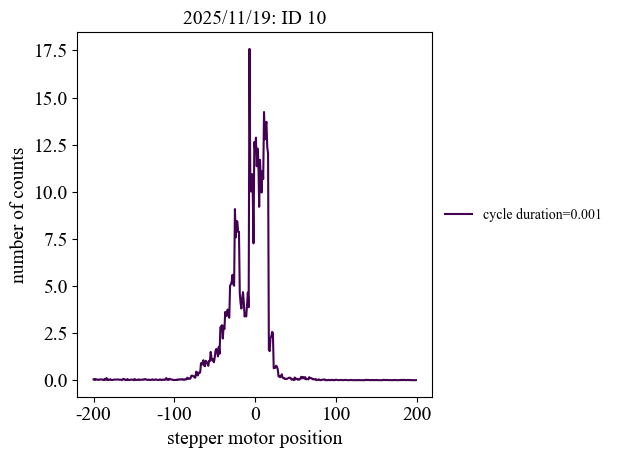

In [17]:
mean_counts = np.mean(np.array(results), axis = 1)
print(mean_counts)
ps.Plot2D(x = x_list - delta, y = T, Z = mean_counts, xlabel = "stepper motor position", ylabel = "cycle duration", zlabel = "number of counts")

**5P 3/2 -- 50 D 3/2 resonance at stepper motor position 3722.**

In [18]:
weeder.save(header = "A", query = True)

'saving complete.'